         PART 1 : TITANIC EDA

 Shape: (891, 12)

 First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



 Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

 Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33



 Missing Values:
Age         177
Cabin       687
Embarked      2
dtype: int64

 Missing values handled.


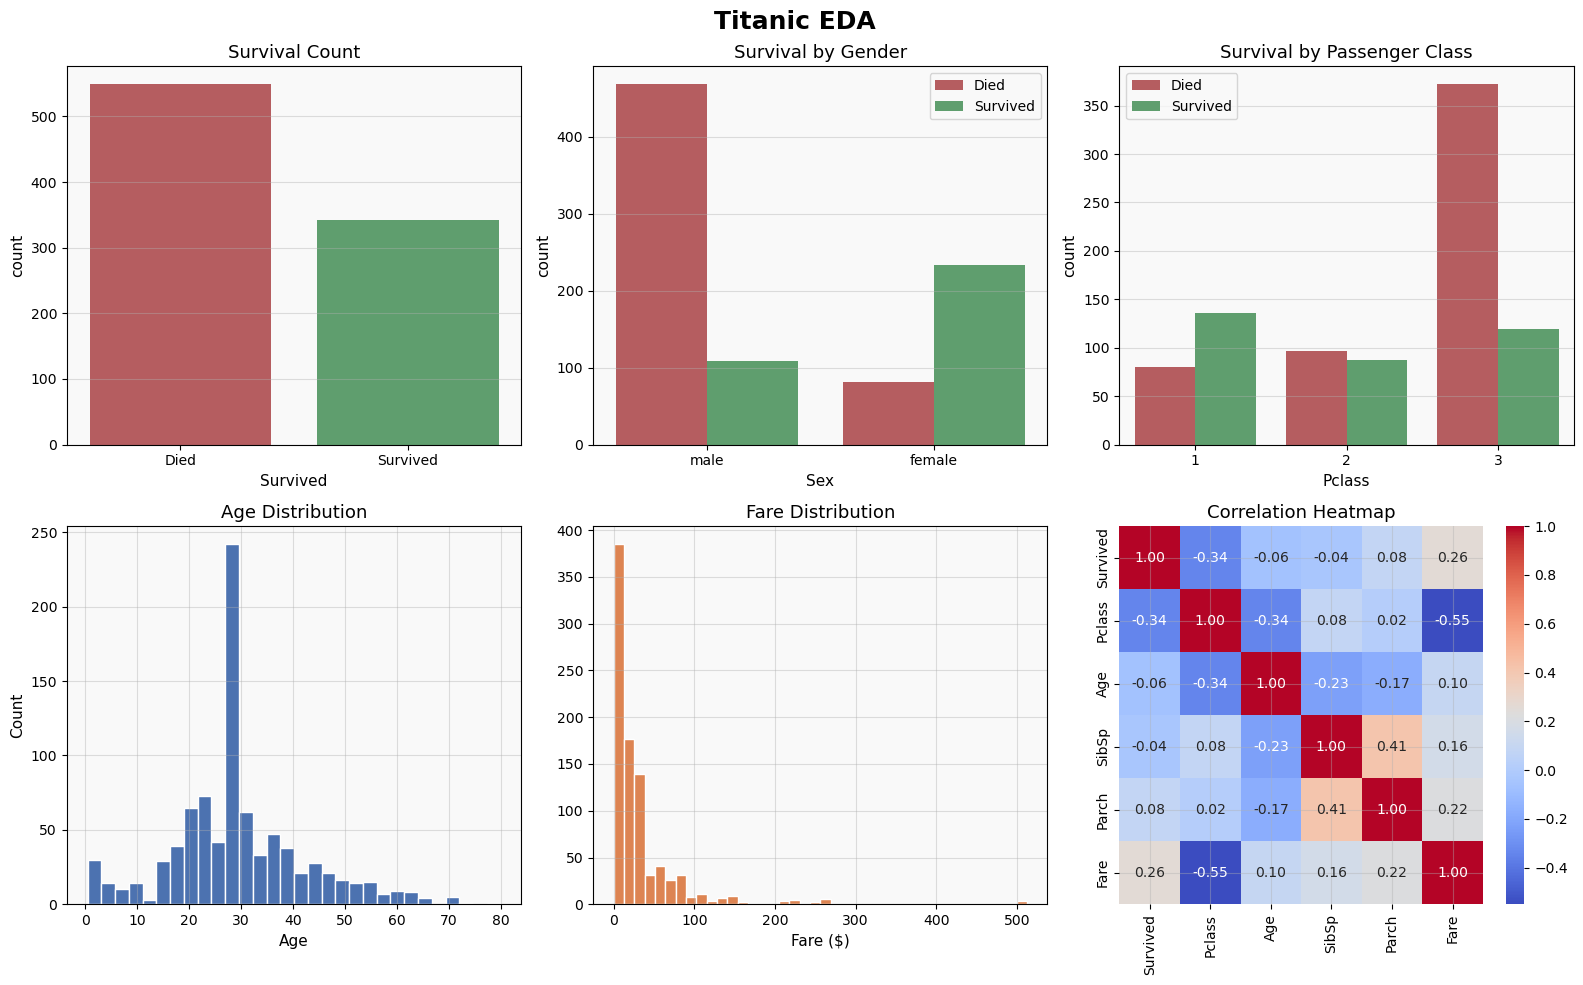

Titanic plots saved.

Key Insights:
   Overall Survival Rate : 38.4%
   Female Survival Rate  : 74.2%
   Male Survival Rate    : 18.9%
   Avg Age               : 29.4 years
   Avg Fare              : $32.20

         PART 2 : IRIS EDA

 Shape: (150, 5)

 First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



 Species Count:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

 Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



 Missing Values: 0 (none)


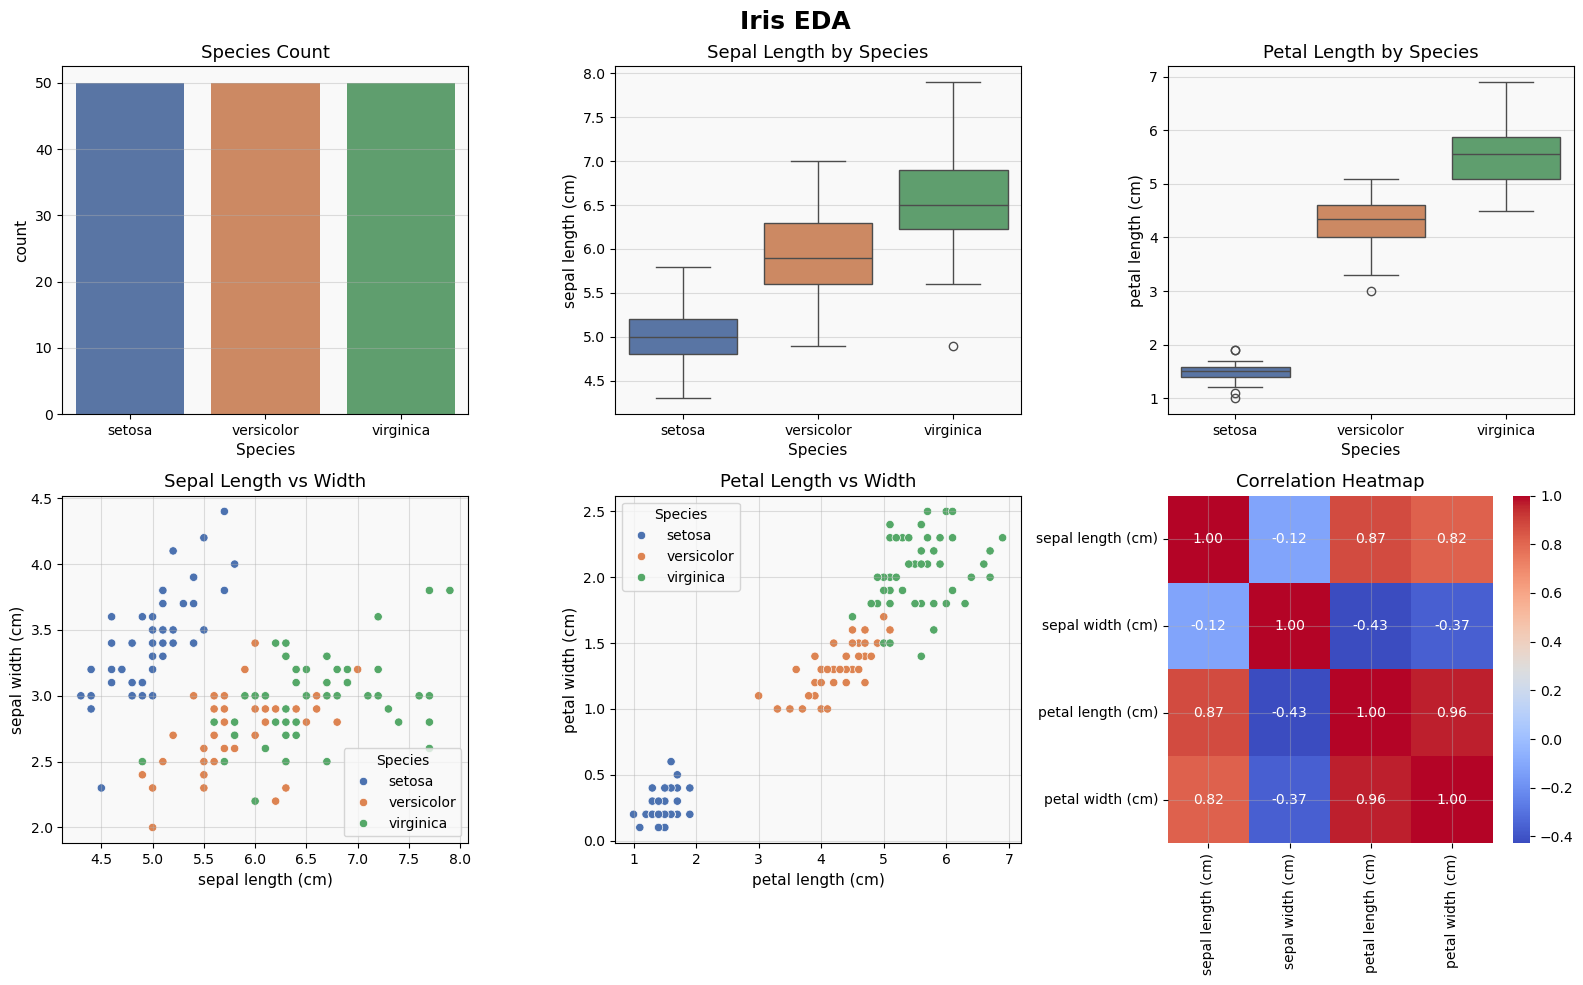

Iris plots saved.

Key Insights:
            sepal length (cm)  petal length (cm)
Species                                         
setosa                   5.01               1.46
versicolor               5.94               4.26
virginica                6.59               5.55

   Petal features are most useful for distinguishing species.
   Setosa is clearly separable; Versicolor & Virginica overlap slightly.


In [ ]:
"""
Exploratory Data Analysis (EDA)
Titanic + Iris Dataset
Horizon Intern - Machine Learning Project A
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

#  PART 1 — TITANIC EDA

print("=" * 55)
print("         PART 1 : TITANIC EDA")
print("=" * 55)

#  Load 
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# Basic Info 
print("\n Shape:", titanic.shape)
print("\n First 5 rows:")
display(titanic.head())

print("\n Data Types & Non-Null Counts:")
print(titanic.info())

print("\n Statistical Summary:")
display(titanic.describe().round(2))

print("\n Missing Values:")
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])

# Cleaning 
titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)
titanic.drop(columns=["Cabin"], inplace=True)
print("\n Missing values handled.")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic EDA", fontsize=18, fontweight="bold")

# 1. Survival Count
sns.countplot(x="Survived", data=titanic, palette=["#C44E52", "#55A868"], ax=axes[0, 0])
axes[0, 0].set_title("Survival Count")
axes[0, 0].set_xticklabels(["Died", "Survived"])

# 2. Survival by Gender
sns.countplot(x="Sex", hue="Survived", data=titanic, palette=["#C44E52", "#55A868"], ax=axes[0, 1])
axes[0, 1].set_title("Survival by Gender")
axes[0, 1].legend(["Died", "Survived"])

# 3. Survival by Pclass
sns.countplot(x="Pclass", hue="Survived", data=titanic, palette=["#C44E52", "#55A868"], ax=axes[0, 2])
axes[0, 2].set_title("Survival by Passenger Class")
axes[0, 2].legend(["Died", "Survived"])

# 4. Age Distribution
axes[1, 0].hist(titanic["Age"], bins=30, color="#4C72B0", edgecolor="white")
axes[1, 0].set_title("Age Distribution")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Count")

# 5. Fare Distribution
axes[1, 1].hist(titanic["Fare"], bins=40, color="#DD8452", edgecolor="white")
axes[1, 1].set_title("Fare Distribution")
axes[1, 1].set_xlabel("Fare ($)")

# 6. Correlation Heatmap
num_cols = titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
sns.heatmap(num_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("titanic_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Titanic plots saved.")

# Key Insights 
survival_rate = titanic["Survived"].mean() * 100
female_survival = titanic[titanic["Sex"] == "female"]["Survived"].mean() * 100
male_survival = titanic[titanic["Sex"] == "male"]["Survived"].mean() * 100

print(f"\nKey Insights:")
print(f"   Overall Survival Rate : {survival_rate:.1f}%")
print(f"   Female Survival Rate  : {female_survival:.1f}%")
print(f"   Male Survival Rate    : {male_survival:.1f}%")
print(f"   Avg Age               : {titanic['Age'].mean():.1f} years")
print(f"   Avg Fare              : ${titanic['Fare'].mean():.2f}")


#  PART 2 — IRIS EDA

print("\n" + "=" * 55)
print("         PART 2 : IRIS EDA")
print("=" * 55)

# Load 
iris_raw = load_iris()
iris = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
iris["Species"] = [iris_raw.target_names[i] for i in iris_raw.target]

# Basic Info
print("\n Shape:", iris.shape)
print("\n First 5 rows:")
display(iris.head())

print("\n Species Count:")
print(iris["Species"].value_counts())

print("\n Statistical Summary:")
display(iris.describe().round(2))

print("\n Missing Values:", iris.isnull().sum().sum(), "(none)")

# Visualizations 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Iris EDA", fontsize=18, fontweight="bold")

palette = {"setosa": "#4C72B0", "versicolor": "#DD8452", "virginica": "#55A868"}

# 1. Species Count
sns.countplot(x="Species", data=iris, palette=palette, ax=axes[0, 0])
axes[0, 0].set_title("Species Count")

# 2. Sepal Length by Species
sns.boxplot(x="Species", y="sepal length (cm)", data=iris, palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("Sepal Length by Species")

# 3. Petal Length by Species
sns.boxplot(x="Species", y="petal length (cm)", data=iris, palette=palette, ax=axes[0, 2])
axes[0, 2].set_title("Petal Length by Species")

# 4. Sepal: Length vs Width
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="Species",
                data=iris, palette=palette, ax=axes[1, 0])
axes[1, 0].set_title("Sepal Length vs Width")

# 5. Petal: Length vs Width
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="Species",
                data=iris, palette=palette, ax=axes[1, 1])
axes[1, 1].set_title("Petal Length vs Width")

# 6. Correlation Heatmap
sns.heatmap(iris.drop(columns="Species").corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("iris_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Iris plots saved.")

# Key Insights 
print(f"\nKey Insights:")
print(iris.groupby("Species")[["sepal length (cm)", "petal length (cm)"]].mean().round(2))
print("\n   Petal features are most useful for distinguishing species.")
print("   Setosa is clearly separable; Versicolor & Virginica overlap slightly.")